In [182]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [183]:
import matplotlib.pyplot as plt
import numpy as np
from os.path import join as pjoin

from cns.process.binning import add_cns_loc, bin_by_break_type, group_bins, bin_by_segments, sum_cns
from cns.display.plot import fig_lines, fig_dots, fig_bars, plot_lines, plot_dots, plot_bars, fig_CN_heatmap, plot_CN_heatmap
from cns.process.segments import merge_segments, filter_min_size, segment_difference, split_segments
from cns.display.label import add_gap_legend, plot_gaps
from cns.utils.conversions import genome_to_segments, tuples_to_segments, cns_to_segments
from cns.utils.selection import cns_head, drop_Y
from cns.utils.assemblies import hg19
from cns.data_utils import load_cns_out, out_path, load_COSMIC

In [184]:
pcawg_cns_df = sum_cns(add_cns_loc(load_cns_out("PCAWG_cns_imp.tsv")))
pcawg_cns_df.head()

,sample_id,chrom,start,end,major_cn,minor_cn,length,mid,cum_mid,total_cn
0,SP1003,chr1,0,37828027,2,2,37828027,18914013,18914013,4
1,SP1003,chr1,37828027,38563006,2,1,734979,38195516,38195516,3
2,SP1003,chr1,38563006,39884821,2,0,1321815,39223913,39223913,2
3,SP1003,chr1,39884821,40536570,16,14,651749,40210695,40210695,30
4,SP1003,chr1,40536570,104039773,2,1,63503203,72288171,72288171,3


In [185]:
genes = cns_to_segments(load_COSMIC())
genes[:5]

[('chr1', 2160134, 2241558),
 ('chr1', 2487078, 2496821),
 ('chr1', 2985732, 3355185),
 ('chr1', 6241329, 6269449),
 ('chr1', 6845384, 7829766)]

In [186]:
pcawg_1_bin_df = add_cns_loc(bin_by_break_type(cns_head(pcawg_cns_df, 1), 100_000))
pcawg_1_groups_df = group_bins(pcawg_1_bin_df)

pcawg_10_bin_df = add_cns_loc(bin_by_break_type(cns_head(pcawg_cns_df, 10), 1_000_000))
pcawg_10_groups_df = group_bins(pcawg_10_bin_df)

pcawg_50_bin_df = add_cns_loc(bin_by_break_type(cns_head(pcawg_cns_df, 50), 10_000_000))
pcawg_50_groups_df = group_bins(pcawg_50_bin_df)

pcawg_arms_bin_df = add_cns_loc(bin_by_break_type(cns_head(pcawg_cns_df, 10), "arms"))
pcawg_arms_groups_df = group_bins(pcawg_arms_bin_df)

gene_bin_df = add_cns_loc(bin_by_segments(cns_head(pcawg_cns_df, 10), genes))
gene_groups_df = group_bins(gene_bin_df)

Binning chr (23/23)
Binning chr (231/231)
Binning chr (1151/1151)
Binning chr (231/231)
Binning chr (231/231)


# Plots

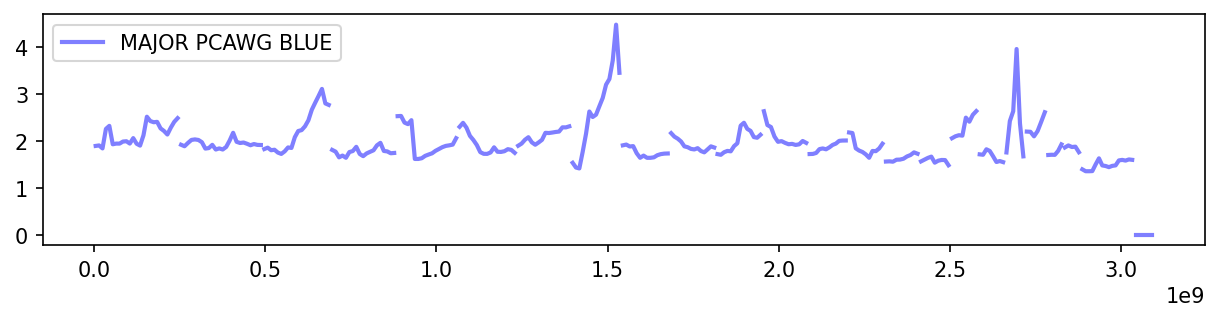

In [187]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_lines(ax, pcawg_50_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 2)
ax.legend()

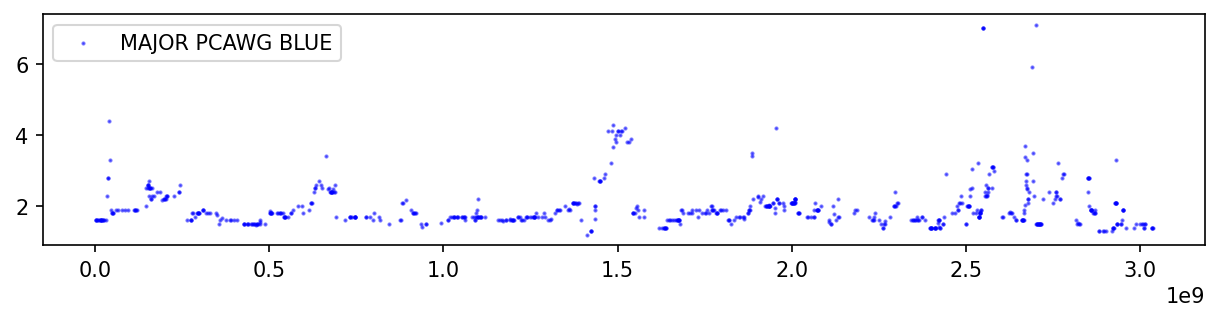

In [188]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_dots(ax, gene_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 1)
ax.legend()

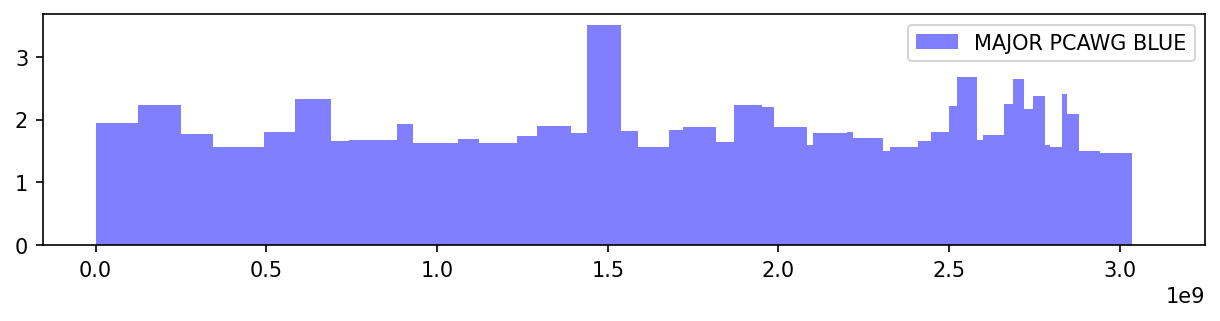

In [189]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_bars(ax, pcawg_arms_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5)
ax.legend()

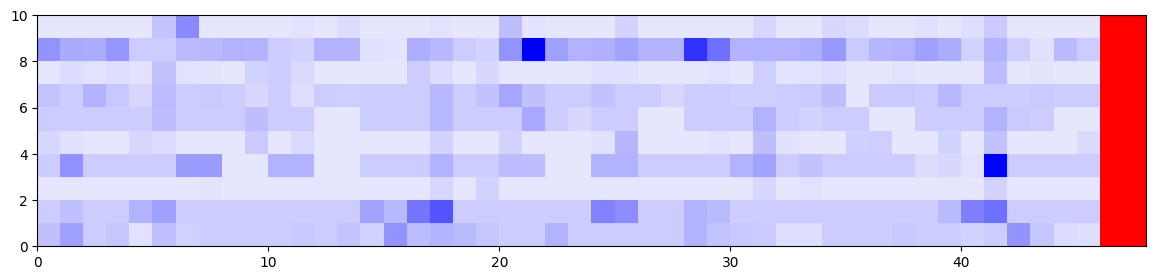

In [190]:
fig, ax = plt.subplots(1, 1, figsize=(24, 3))
plot_CN_heatmap(ax, pcawg_arms_bin_df, "major_cn");

# Figures

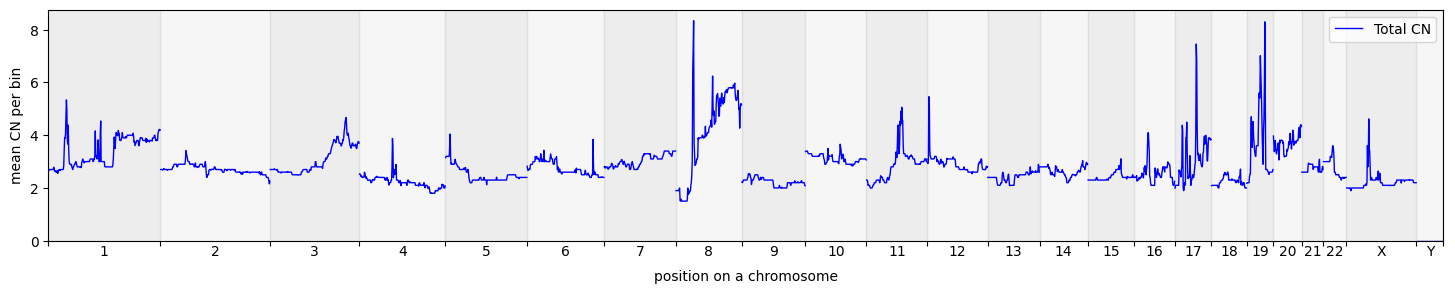

In [191]:
max_cn = np.ceil(pcawg_10_groups_df["total_cn"].max())
fig_lines(pcawg_10_groups_df, column="total_cn", label="Total CN", color="blue");

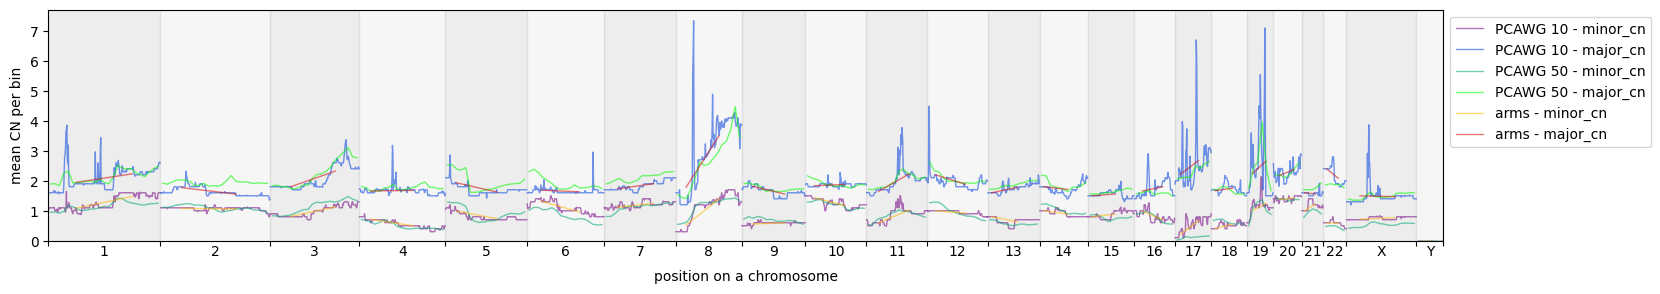

In [192]:
fig, ax = fig_lines([pcawg_10_groups_df, pcawg_50_groups_df, pcawg_arms_groups_df], label=["PCAWG 10", "PCAWG 50", "arms"], column=["minor_cn", "major_cn"])

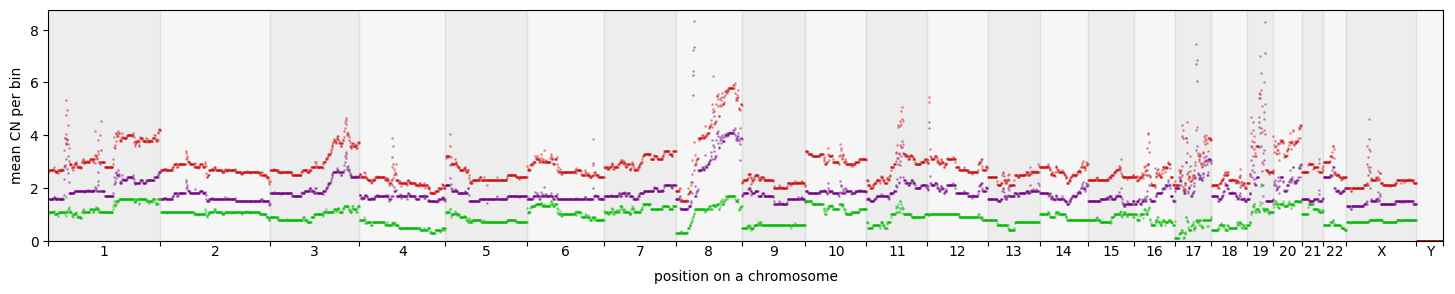

In [193]:
fig_dots(pcawg_10_groups_df);

(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on a chromosome', ylabel='mean CN per bin'>)

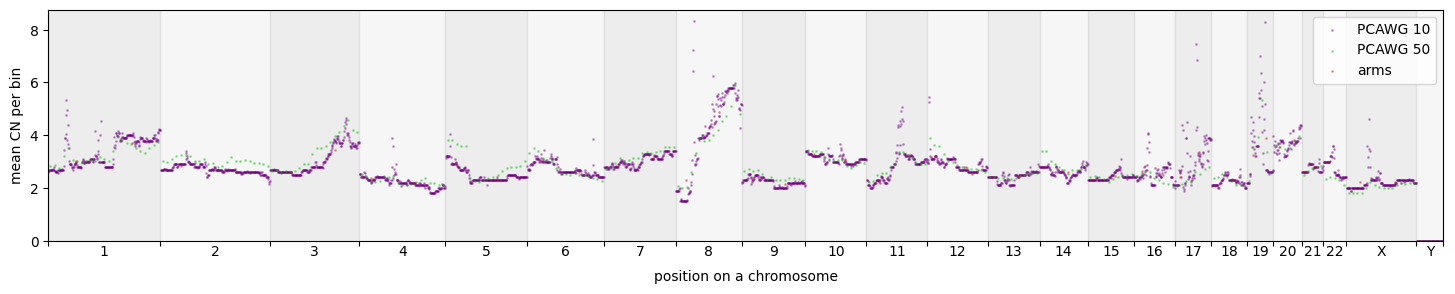

In [194]:
fig_dots([pcawg_10_groups_df, pcawg_50_groups_df, pcawg_arms_groups_df], ["PCAWG 10", "PCAWG 50", "arms"], column="total_cn")

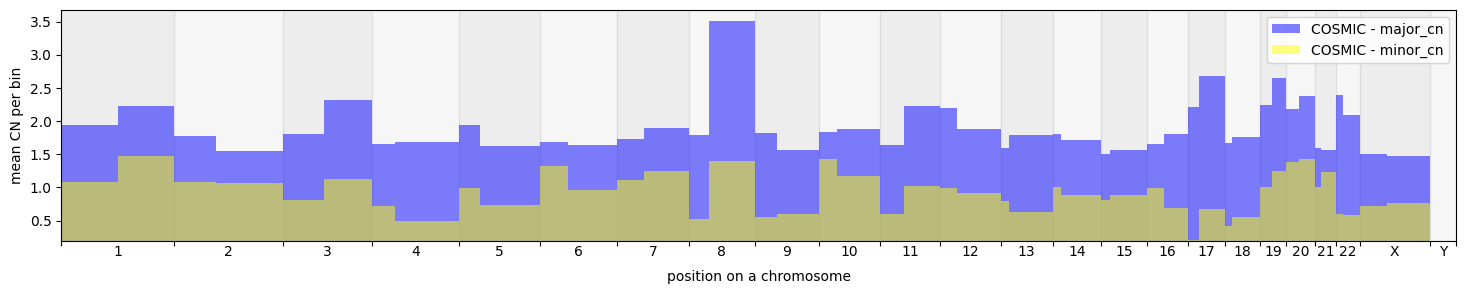

In [209]:
fig_bars(drop_Y(pcawg_arms_groups_df), column=["major_cn", "minor_cn"], color=["blue", "yellow"], label="COSMIC");

## Single Chrom Only

In [196]:
step_size = int(1e6)
# only keep gaps at least half the step size
gaps_hg19_segs = tuples_to_segments(hg19.gaps)
genome_segs = genome_to_segments(hg19)
merged_hg19_gaps = merge_segments(gaps_hg19_segs)
filtered_gaps = filter_min_size(merged_hg19_gaps, step_size // 2)
filtered_genome = segment_difference(genome_segs, filtered_gaps)
filtered_segs = split_segments(filtered_genome, step_size)
filtered_cns = bin_by_segments(cns_head(pcawg_cns_df, 10), filtered_segs)

Binning chr (231/231)


Text(0.5, 1.0, 'Mean Copy Number across the genome, gaps removed')

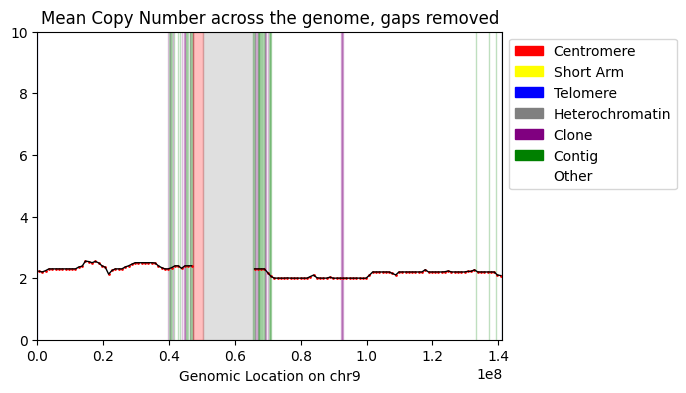

In [197]:
with_loc = add_cns_loc(filtered_cns)
grouped_bins = group_bins(with_loc)
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=100)
plot_gaps(ax, alpha=.25, y_max=10, sel_chrom="chr9")
add_gap_legend(ax)
plot_lines(ax, grouped_bins, "total_cn", color="black", chrom="chr9")
plot_dots(ax, grouped_bins, "total_cn", color="red", chrom="chr9")
# no_y_ticks(ax)
# add lables
ax.set_xlabel("Genomic Location on chr9")
# ax.set_ylabel("Mean Copy Number")
ax.set_title("Mean Copy Number across the genome, gaps removed")

# CN Heatmaps

Figure size in inches: [18.    1.36] (Width x Height)
Ax size in inches: [17.7         0.87411502] (Width x Height)
Ax coordinates within the figure:
	Left: 0.00833333333333336
	Bottom: 0.1786341835481846
	Right: 0.9916666666666667
	Top: 0.8213658164518154
image_pixes:  [(607, 30363)]
dpi:  100
Top size:  0.1323529411764706


(<Figure size 1800x136 with 2 Axes>,
 <Axes: xlabel='total_cn', ylabel='sample'>)

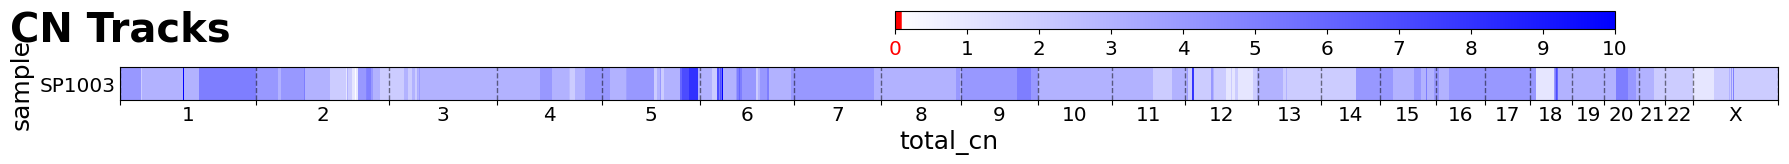

In [203]:
fig_CN_heatmap(pcawg_1_bin_df, print_info=True, max_cn=10)

Figure size in inches: [2. 5.] (Width x Height)
Ax size in inches: [1.50567361 4.7       ] (Width x Height)
Ax coordinates within the figure:
	Left: 0.12358159722222217
	Bottom: 0.02999999999999997
	Right: 0.8764184027777778
	Top: 0.97
image_pixes:  [(10, 2)]
dpi:  100
Top size:  0.04


(<Figure size 200x500 with 2 Axes>, <Axes: xlabel='total_cn', ylabel='sample'>)

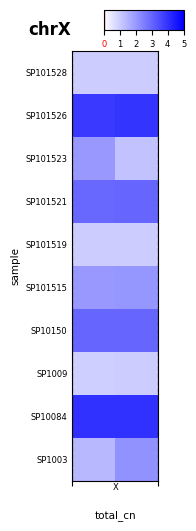

In [204]:
fig_CN_heatmap(pcawg_arms_bin_df, chrom="chrX", label="chrX", print_info=True, max_cn=10)

Figure size in inches: [16.   2.6] (Width x Height)
Ax size in inches: [7.46010417 1.88846801] (Width x Height)
Ax coordinates within the figure:
	Left: 0.03374348958333351
	Bottom: 0.1368330745293343
	Right: 0.9662565104166665
	Top: 0.8631669254706658
image_pixes:  [(620, 3093), (620, 3093)]
dpi:  100
Top size:  0.03076923076923077


(<Figure size 1600x260 with 3 Axes>,
 array([<Axes: xlabel='major_cn', ylabel='sample'>,
        <Axes: xlabel='minor_cn'>], dtype=object))

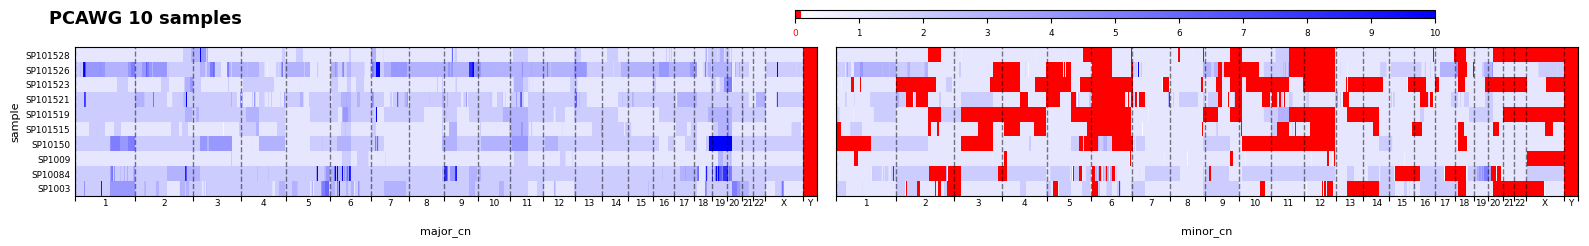

In [205]:
fig_CN_heatmap(pcawg_10_bin_df, "PCAWG 10 samples", width=16, column=["major_cn", "minor_cn"], max_cn=10, print_info=True)

(<Figure size 700x800 with 2 Axes>, <Axes: xlabel='total_cn', ylabel='sample'>)

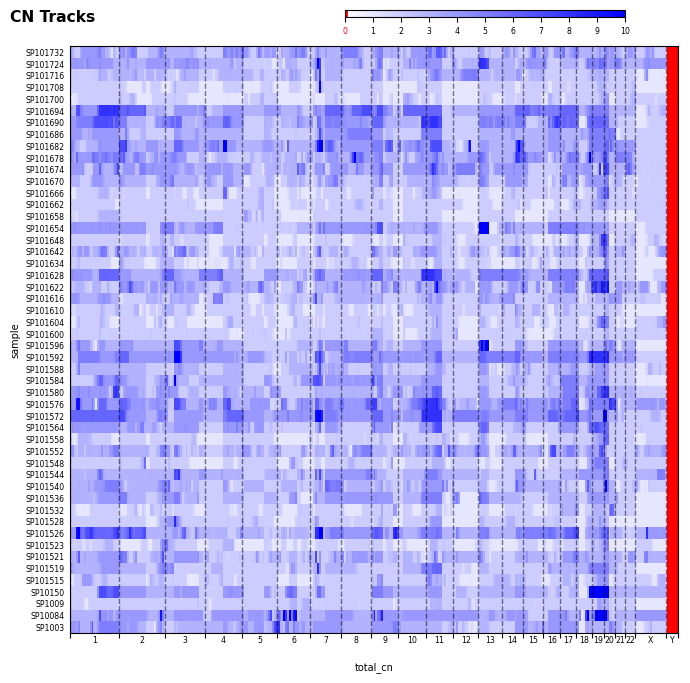

In [206]:
fig_CN_heatmap(pcawg_50_bin_df, width=7, max_cn=10)

In [207]:
pcawg_500_bin_df = add_cns_loc(bin_by_break_type(cns_head(pcawg_cns_df, 500), 10_000_000))
print("Creating heatmap.... ")
fig_CN_heatmap(pcawg_500_bin_df, vertical_legend_correction=0.0025);
# create directory out if not exist

plt.savefig(pjoin(out_path, "pcawg_500_tracks.png"), dpi=150)
plt.close()

Binning chr (11784/11784)
Creating heatmap.... 
